# 🧠 Multi-Model RAG System
> **Fully offline** · FAISS HNSW vector store · bge-m3 embeddings · GLM-OCR local LLM

---
## 📋 Notebook Sections
| # | Section | Description |
|---|---------|-------------|
| 0 | **Setup & Config** | Install check, .env loader, global config |
| 1 | **Data Ingestion** | Load PDF, images, CSV, code files |
| 2 | **Chunking** | Split docs into searchable chunks |
| 3 | **Embedding** | Encode chunks with bge-m3 (local) |
| 4 | **Vector Store (FAISS)** | Build HNSW index, save/load |
| 5 | **Retrieval** | Hybrid dense+sparse search + re-ranking |
| 6 | **GLM-OCR Connector** | Connect to your local GLM-OCR model |
| 7 | **RAG Pipeline** | Full query → retrieve → generate loop |
| 8 | **Evaluation** | ROUGE, precision@k metrics |

---
⚡ **Run sections in order on first setup.** After that you can jump to Section 7 directly.

---
## Section 0 — Setup & Configuration

In [1]:
# ── Section 0A: Verify installs ───────────────────────────────────────────────
import importlib, sys

REQUIRED = [
    'faiss', 'sentence_transformers', 'langchain', 'pypdf',
    'pdfplumber', 'pandas', 'PIL', 'rank_bm25', 'sklearn',
    'requests', 'dotenv', 'tinydb', 'tqdm', 'rich'
]

missing = []
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
        print(f'  ✅  {pkg}')
    except ImportError:
        missing.append(pkg)
        print(f'  ❌  {pkg}  ← NOT FOUND')

if missing:
    print(f'\n⚠️  Missing packages: {missing}')
    print('Run:  pip install -r requirements.txt')
else:
    print('\n✅  All packages ready. Fully offline mode active.')

  ✅  faiss


/home/shamanth/ocr_check/files/.venv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


  ✅  sentence_transformers
  ✅  langchain
  ✅  pypdf
  ✅  pdfplumber
  ✅  pandas
  ✅  PIL
  ✅  rank_bm25
  ✅  sklearn
  ✅  requests
  ✅  dotenv
  ✅  tinydb
  ✅  tqdm
  ✅  rich

✅  All packages ready. Fully offline mode active.


In [2]:
# ── Section 0B: Global Config ─────────────────────────────────────────────────
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()  # loads from .env file if present

# ─── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(".")                     # project root
DATA_DIR        = BASE_DIR / "data"             # put your files here
INDEX_DIR       = BASE_DIR / "faiss_index"      # saved FAISS index
METADATA_DIR    = BASE_DIR / "metadata"         # TinyDB metadata store
MODELS_CACHE    = BASE_DIR / "models_cache"     # HuggingFace model cache
LOGS_DIR        = BASE_DIR / "logs"             # log files

for d in [DATA_DIR, INDEX_DIR, METADATA_DIR, MODELS_CACHE, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Embedding config ─────────────────────────────────────────────────────────
EMBED_MODEL_NAME  = os.getenv("EMBED_MODEL", "BAAI/bge-m3")
EMBED_DEVICE      = os.getenv("EMBED_DEVICE", "cpu")     # 'cuda' if GPU available
EMBED_BATCH_SIZE  = int(os.getenv("EMBED_BATCH", "32"))
EMBED_DIM         = 1024                                  # bge-m3 output dim

# ─── Chunking config ──────────────────────────────────────────────────────────
CHUNK_SIZE        = int(os.getenv("CHUNK_SIZE", "512"))   # tokens per chunk
CHUNK_OVERLAP     = int(os.getenv("CHUNK_OVERLAP", "64")) # overlap between chunks

# ─── FAISS config ─────────────────────────────────────────────────────────────
FAISS_INDEX_FILE  = INDEX_DIR / "hnsw.index"
FAISS_M           = 32       # HNSW: number of connections per node
FAISS_EF_SEARCH   = 64       # HNSW: search depth (higher = more accurate)
FAISS_EF_CONSTRUCT = 200     # HNSW: build quality

# ─── Retrieval config ─────────────────────────────────────────────────────────
TOP_K_DENSE   = int(os.getenv("TOP_K_DENSE", "10"))  # dense retrieval candidates
TOP_K_SPARSE  = int(os.getenv("TOP_K_SPARSE", "10")) # BM25 candidates
TOP_K_FINAL   = int(os.getenv("TOP_K_FINAL", "5"))   # after re-ranking
RERANK_MODEL  = os.getenv("RERANK_MODEL", "cross-encoder/ms-marco-MiniLM-L-6-v2")

# ─── GLM-OCR local API config ─────────────────────────────────────────────────
GLM_HOST      = os.getenv("GLM_HOST", "http://localhost")
GLM_PORT      = int(os.getenv("GLM_PORT", "8000"))
GLM_BASE_URL  = f"{GLM_HOST}:{GLM_PORT}"
GLM_MODEL     = os.getenv("GLM_MODEL", "glm-ocr")   # model name your server expects
GLM_TIMEOUT   = int(os.getenv("GLM_TIMEOUT", "120"))
GLM_MAX_TOKENS = int(os.getenv("GLM_MAX_TOKENS", "2048"))
GLM_TEMPERATURE = float(os.getenv("GLM_TEMPERATURE", "0.1"))

print("📁  Directories:")
print(f"   data/         → {DATA_DIR.resolve()}")
print(f"   faiss_index/  → {INDEX_DIR.resolve()}")
print(f"   metadata/     → {METADATA_DIR.resolve()}")
print(f"\n🤖  Embedding model : {EMBED_MODEL_NAME} on {EMBED_DEVICE}")
print(f"🗄️  FAISS index     : HNSW  M={FAISS_M}  ef={FAISS_EF_SEARCH}")
print(f"🌐  GLM-OCR API     : {GLM_BASE_URL}")

📁  Directories:
   data/         → /home/shamanth/ocr_check/files/data
   faiss_index/  → /home/shamanth/ocr_check/files/faiss_index
   metadata/     → /home/shamanth/ocr_check/files/metadata

🤖  Embedding model : BAAI/bge-m3 on cpu
🗄️  FAISS index     : HNSW  M=32  ef=64
🌐  GLM-OCR API     : http://localhost:11434


---
## Section 1 — Data Ingestion
Loads files from the `data/` folder.  
Supported formats: **PDF, DOCX, TXT, MD, PNG, JPG, CSV, XLSX, .py / .js / .java**

📂 **How to add your files:** Place any supported file into the `data/` folder and re-run this section.

In [3]:
# ── Section 1A: File type detection & loader registry ────────────────────────
import logging
import hashlib
import json
from datetime import datetime
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import pypdf
import pdfplumber
import pandas as pd
from PIL import Image
from docx import Document as DocxDocument
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
log = logging.getLogger('RAG.Ingestion')


@dataclass
class RawDocument:
    """Represents one loaded file before chunking."""
    doc_id:     str
    file_path:  str
    file_type:  str           # 'pdf' | 'image' | 'csv' | 'code' | 'text'
    content:    str           # raw text extracted
    metadata:   Dict          = field(default_factory=dict)
    has_images: bool          = False
    image_paths: List[str]    = field(default_factory=list)


def file_hash(path: Path) -> str:
    """MD5 hash for deduplication."""
    return hashlib.md5(path.read_bytes()).hexdigest()[:12]


# ─── PDF Loader ───────────────────────────────────────────────────────────────
def load_pdf(path: Path) -> RawDocument:
    text_parts = []
    image_paths = []

    # Use pdfplumber for text + table extraction
    with pdfplumber.open(path) as pdf:
        for i, page in enumerate(pdf.pages):
            page_text = page.extract_text() or ""
            tables = page.extract_tables()
            if tables:
                for tbl in tables:
                    df = pd.DataFrame(tbl[1:], columns=tbl[0])
                    page_text += "\n[TABLE]\n" + df.to_string(index=False) + "\n"
            text_parts.append(f"[Page {i+1}]\n{page_text}")

    full_text = "\n\n".join(text_parts)

    # If text is sparse → mark for GLM-OCR processing
    needs_ocr = len(full_text.strip()) < 100

    return RawDocument(
        doc_id    = file_hash(path),
        file_path = str(path),
        file_type = "pdf",
        content   = full_text,
        metadata  = {
            "filename": path.name,
            "pages":    len(text_parts),
            "needs_ocr": needs_ocr,
            "ingested_at": datetime.now().isoformat()
        }
    )


# ─── Image Loader ─────────────────────────────────────────────────────────────
def load_image(path: Path) -> RawDocument:
    img = Image.open(path)
    return RawDocument(
        doc_id     = file_hash(path),
        file_path  = str(path),
        file_type  = "image",
        content    = f"[IMAGE: {path.name}  size={img.size}  mode={img.mode}]",
        has_images = True,
        image_paths = [str(path)],
        metadata   = {
            "filename": path.name,
            "size":     img.size,
            "mode":     img.mode,
            "needs_ocr": True,
            "ingested_at": datetime.now().isoformat()
        }
    )


# ─── CSV / Excel Loader ───────────────────────────────────────────────────────
def load_tabular(path: Path) -> RawDocument:
    if path.suffix.lower() in ('.xlsx', '.xls'):
        df = pd.read_excel(path)
    else:
        try:
            df = pd.read_csv(path)
        except Exception:
            df = pd.read_csv(path, encoding='latin1')

    # Serialize: schema header + sample rows + full markdown table
    schema = "COLUMNS: " + ", ".join([f"{c} ({df[c].dtype})" for c in df.columns])
    sample = df.head(5).to_string(index=False)
    full   = df.to_string(index=False)
    content = f"{schema}\n\nSAMPLE:\n{sample}\n\nFULL DATA:\n{full}"

    return RawDocument(
        doc_id    = file_hash(path),
        file_path = str(path),
        file_type = "csv",
        content   = content,
        metadata  = {
            "filename": path.name,
            "rows":     len(df),
            "cols":     len(df.columns),
            "columns":  list(df.columns),
            "ingested_at": datetime.now().isoformat()
        }
    )


# ─── Code Loader ──────────────────────────────────────────────────────────────
CODE_EXTENSIONS = {'.py', '.js', '.ts', '.java', '.cpp', '.c', '.go', '.rs', '.rb', '.sh'}

def load_code(path: Path) -> RawDocument:
    content = path.read_text(errors='replace')
    lang = path.suffix.lstrip('.')
    return RawDocument(
        doc_id    = file_hash(path),
        file_path = str(path),
        file_type = "code",
        content   = f"```{lang}\n{content}\n```",
        metadata  = {
            "filename": path.name,
            "language": lang,
            "lines":    content.count('\n'),
            "ingested_at": datetime.now().isoformat()
        }
    )


# ─── Plain text / DOCX / MD loader ────────────────────────────────────────────
def load_text(path: Path) -> RawDocument:
    if path.suffix.lower() == '.docx':
        doc = DocxDocument(path)
        content = "\n".join(p.text for p in doc.paragraphs if p.text.strip())
    elif path.suffix.lower() == '.html':
        soup = BeautifulSoup(path.read_bytes(), 'lxml')
        content = soup.get_text(separator='\n')
    else:
        content = path.read_text(errors='replace')

    return RawDocument(
        doc_id    = file_hash(path),
        file_path = str(path),
        file_type = "text",
        content   = content,
        metadata  = {"filename": path.name, "ingested_at": datetime.now().isoformat()}
    )


# ─── Master router ────────────────────────────────────────────────────────────
def load_file(path: Path) -> Optional[RawDocument]:
    ext = path.suffix.lower()
    if ext == '.pdf':                          return load_pdf(path)
    if ext in ('.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff'):
                                               return load_image(path)
    if ext in ('.csv', '.xlsx', '.xls'):       return load_tabular(path)
    if ext in CODE_EXTENSIONS:                 return load_code(path)
    if ext in ('.txt', '.md', '.docx', '.html', '.rst'):
                                               return load_text(path)
    log.warning(f'Skipping unsupported file: {path.name}')
    return None


print('✅  Loaders registered for: PDF | Image | CSV/Excel | Code | Text/DOCX/MD')

✅  Loaders registered for: PDF | Image | CSV/Excel | Code | Text/DOCX/MD


In [4]:
# ── Section 1B: Scan data/ folder and load all files ─────────────────────────

all_files = sorted(DATA_DIR.rglob('*'))
all_files = [f for f in all_files if f.is_file() and not f.name.startswith('.')]

if not all_files:
    print("⚠️  No files found in data/ folder.")
    print("    Add your PDF, image, CSV, or code files to:")
    print(f"    {DATA_DIR.resolve()}")
    print("    Then re-run this cell.")
else:
    print(f"📂  Found {len(all_files)} files in data/\n")
    raw_documents: List[RawDocument] = []
    failed = []

    for fpath in tqdm(all_files, desc='Loading files'):
        try:
            doc = load_file(fpath)
            if doc:
                raw_documents.append(doc)
        except Exception as e:
            failed.append((fpath.name, str(e)))
            log.error(f'Failed to load {fpath.name}: {e}')

    # Summary
    from collections import Counter
    type_counts = Counter(d.file_type for d in raw_documents)
    print(f'\n📊  Loaded {len(raw_documents)} documents:')
    for ftype, count in type_counts.items():
        print(f'   {ftype:12s} → {count} file(s)')

    ocr_needed = [d for d in raw_documents if d.metadata.get('needs_ocr')]
    if ocr_needed:
        print(f'\n🔍  {len(ocr_needed)} file(s) need GLM-OCR (scanned/images) — handled in Section 6')

    if failed:
        print(f'\n❌  {len(failed)} failed:')
        for name, err in failed:
            print(f'   {name}: {err}')

📂  Found 3 files in data/



Loading files:   0%|          | 0/3 [00:00<?, ?it/s]

WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
WARNING | Could not get FontBBox from fo


📊  Loaded 3 documents:
   pdf          → 2 file(s)
   image        → 1 file(s)

🔍  1 file(s) need GLM-OCR (scanned/images) — handled in Section 6


---
## Section 2 — Chunking
Splits raw documents into overlapping chunks that fit within the embedding window.  
Uses **recursive character splitting** with token-aware sizing.

In [5]:
# ── Section 2: Chunking ───────────────────────────────────────────────────────
from dataclasses import dataclass
from langchain.text_splitter import RecursiveCharacterTextSplitter
import tiktoken


@dataclass
class Chunk:
    """A single searchable chunk with full provenance."""
    chunk_id:    str
    doc_id:      str
    file_path:   str
    file_type:   str
    text:        str
    chunk_index: int
    total_chunks: int
    metadata:    Dict


# Token counter (offline cl100k_base tokenizer)
try:
    _enc = tiktoken.get_encoding("cl100k_base")
    def count_tokens(text: str) -> int:
        return len(_enc.encode(text))
except Exception:
    def count_tokens(text: str) -> int:
        return len(text.split())


def make_splitter(chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP):
    return RecursiveCharacterTextSplitter(
        chunk_size         = chunk_size,
        chunk_overlap      = overlap,
        length_function    = count_tokens,
        separators         = ["\n\n", "\n", ". ", " ", ""],
        keep_separator     = True,
    )


def chunk_document(doc: RawDocument, splitter) -> List[Chunk]:
    """Chunk a single RawDocument into a list of Chunk objects."""
    if doc.file_type == 'image':
        # Images are single-chunk — text will be filled by OCR in Section 6
        return [Chunk(
            chunk_id     = f"{doc.doc_id}_0",
            doc_id       = doc.doc_id,
            file_path    = doc.file_path,
            file_type    = doc.file_type,
            text         = doc.content,
            chunk_index  = 0,
            total_chunks = 1,
            metadata     = {**doc.metadata, 'is_image_chunk': True}
        )]

    raw_chunks = splitter.split_text(doc.content)
    chunks = []
    for i, text in enumerate(raw_chunks):
        chunks.append(Chunk(
            chunk_id      = f"{doc.doc_id}_{i}",
            doc_id        = doc.doc_id,
            file_path     = doc.file_path,
            file_type     = doc.file_type,
            text          = text.strip(),
            chunk_index   = i,
            total_chunks  = len(raw_chunks),
            metadata      = {**doc.metadata, 'chunk_index': i, 'total_chunks': len(raw_chunks)}
        ))
    return chunks


# Run chunking
splitter = make_splitter()
all_chunks: List[Chunk] = []

for doc in tqdm(raw_documents, desc='Chunking documents'):
    chunks = chunk_document(doc, splitter)
    all_chunks.extend(chunks)

token_counts = [count_tokens(c.text) for c in all_chunks]
print(f'\n✂️  Chunking complete:')
print(f'   Total chunks   : {len(all_chunks)}')
print(f'   Avg tokens/chunk: {sum(token_counts)//len(token_counts) if token_counts else 0}')
print(f'   Max tokens     : {max(token_counts) if token_counts else 0}')
print(f'   Min tokens     : {min(token_counts) if token_counts else 0}')

Chunking documents:   0%|          | 0/3 [00:00<?, ?it/s]


✂️  Chunking complete:
   Total chunks   : 10
   Avg tokens/chunk: 355
   Max tokens     : 499
   Min tokens     : 33


---
## Section 3 — Embedding
Encodes all chunks using **bge-m3** locally (no internet).  
bge-m3 produces 1024-dimensional dense vectors and also supports sparse retrieval.

In [18]:
# ── Section 3: Embedding with bge-m3 (sentence-transformers) ─────────────────
import numpy as np
import os
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm

os.environ['TRANSFORMERS_CACHE'] = str(MODELS_CACHE)
os.environ['TRANSFORMERS_OFFLINE'] = '1'  # allow download on first run

print(f'📥  Loading embedding model: {EMBED_MODEL_NAME}')
print(f'    Device : {EMBED_DEVICE}')
print(f'    Cache  : {MODELS_CACHE}')

embed_model = SentenceTransformer(
    'BAAI/bge-m3',
    device=EMBED_DEVICE,
    cache_folder=str(MODELS_CACHE)
)

os.environ['TRANSFORMERS_OFFLINE'] = '1'  # lock offline after load
print('✅  bge-m3 loaded\n')


def embed_chunks(chunks, batch_size=EMBED_BATCH_SIZE):
    texts = [c.text for c in chunks]
    all_vecs = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Embedding batches'):
        batch = texts[i:i+batch_size]
        vecs = embed_model.encode(batch, normalize_embeddings=True, show_progress_bar=False)
        all_vecs.append(vecs)
    return np.vstack(all_vecs).astype('float32')


def embed_query(text):
    vec = embed_model.encode([text], normalize_embeddings=True)
    return vec.astype('float32')


print(f'⚙️  Embedding {len(all_chunks)} chunks...')
chunk_embeddings = embed_chunks(all_chunks)
print(f'✅  Embeddings shape: {chunk_embeddings.shape}')

INFO | Load pretrained SentenceTransformer: BAAI/bge-m3


📥  Loading embedding model: BAAI/bge-m3
    Device : cpu
    Cache  : models_cache


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅  bge-m3 loaded

⚙️  Embedding 10 chunks...


Embedding batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅  Embeddings shape: (10, 1024)


---
## Section 4 — Vector Store (FAISS HNSW)
Builds and persists a FAISS HNSW index locally.  
Also saves chunk metadata to TinyDB for provenance tracking.

In [19]:
# ── Section 4A: Build FAISS HNSW index ────────────────────────────────────────
import faiss
import pickle
from tinydb import TinyDB, Query

print(f'⚙️  Building FAISS HNSW index...')
print(f'   Dimensions : {EMBED_DIM}')
print(f'   Vectors    : {len(chunk_embeddings)}')
print(f'   M          : {FAISS_M}  (connections/node)')
print(f'   efConstruct: {FAISS_EF_CONSTRUCT}')
print(f'   efSearch   : {FAISS_EF_SEARCH}\n')

# HNSW index — approximate nearest neighbour, very fast at search time
index = faiss.IndexHNSWFlat(EMBED_DIM, FAISS_M, faiss.METRIC_INNER_PRODUCT)
index.hnsw.efConstruction = FAISS_EF_CONSTRUCT
index.hnsw.efSearch        = FAISS_EF_SEARCH

# Normalize vectors for cosine similarity via inner product
faiss.normalize_L2(chunk_embeddings)
index.add(chunk_embeddings)

print(f'✅  HNSW index built — {index.ntotal} vectors indexed')


# ── Section 4B: Save index + metadata ─────────────────────────────────────────
faiss.write_index(index, str(FAISS_INDEX_FILE))
print(f'💾  FAISS index saved → {FAISS_INDEX_FILE}')

# Save chunk list (for lookup by FAISS integer ID)
chunk_store_path = INDEX_DIR / 'chunks.pkl'
with open(chunk_store_path, 'wb') as f:
    pickle.dump(all_chunks, f)
print(f'💾  Chunk store saved → {chunk_store_path}')

# Save metadata to TinyDB
db = TinyDB(METADATA_DIR / 'metadata.json')
db.truncate()  # clear on rebuild
db.insert_multiple([
    {
        'chunk_id':    c.chunk_id,
        'doc_id':      c.doc_id,
        'file_path':   c.file_path,
        'file_type':   c.file_type,
        'chunk_index': c.chunk_index,
        'metadata':    c.metadata,
        'text_preview': c.text[:200]
    }
    for c in all_chunks
])
print(f'💾  Metadata saved  → {METADATA_DIR / "metadata.json"} ({len(all_chunks)} records)')


# ── Section 4C: Load index (use this cell to reload without rebuilding) ───────
def load_vector_store():
    """Load existing FAISS index + chunk store from disk."""
    loaded_index  = faiss.read_index(str(FAISS_INDEX_FILE))
    loaded_index.hnsw.efSearch = FAISS_EF_SEARCH
    with open(chunk_store_path, 'rb') as f:
        loaded_chunks = pickle.load(f)
    print(f'✅  Loaded FAISS index: {loaded_index.ntotal} vectors')
    print(f'✅  Loaded {len(loaded_chunks)} chunks')
    return loaded_index, loaded_chunks


print(f'\n✅  Vector store ready.')
print('    To reload without rebuilding: call  load_vector_store()')

⚙️  Building FAISS HNSW index...
   Dimensions : 1024
   Vectors    : 10
   M          : 32  (connections/node)
   efConstruct: 200
   efSearch   : 64

✅  HNSW index built — 10 vectors indexed
💾  FAISS index saved → faiss_index/hnsw.index
💾  Chunk store saved → faiss_index/chunks.pkl
💾  Metadata saved  → metadata/metadata.json (10 records)

✅  Vector store ready.
    To reload without rebuilding: call  load_vector_store()


---
## Section 5 — Retrieval
**Hybrid search**: dense (FAISS) + sparse (BM25) fused with Reciprocal Rank Fusion.  
**Re-ranking**: cross-encoder scores the top candidates for final ordering.

In [20]:
# ── Section 5A: Dense retrieval (FAISS HNSW) ──────────────────────────────────
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder


def dense_search(query: str, k: int = TOP_K_DENSE) -> List[Dict]:
    """Search FAISS index, return top-k chunks with scores."""
    q_vec = embed_query(query)
    faiss.normalize_L2(q_vec)
    scores, indices = index.search(q_vec, k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:  # FAISS returns -1 for empty slots
            continue
        results.append({
            'chunk':  all_chunks[idx],
            'score':  float(score),
            'source': 'dense',
            'rank':   len(results) + 1
        })
    return results


# ── Section 5B: Sparse retrieval (BM25) ───────────────────────────────────────
print('⚙️  Building BM25 index (fast, in-memory)...')
tokenized_corpus = [c.text.lower().split() for c in all_chunks]
bm25 = BM25Okapi(tokenized_corpus)
print(f'✅  BM25 ready over {len(all_chunks)} chunks')


def sparse_search(query: str, k: int = TOP_K_SPARSE) -> List[Dict]:
    """BM25 keyword search."""
    tokens   = query.lower().split()
    raw_scores = bm25.get_scores(tokens)
    top_idxs = np.argsort(raw_scores)[::-1][:k]

    results = []
    for rank, idx in enumerate(top_idxs):
        results.append({
            'chunk':  all_chunks[idx],
            'score':  float(raw_scores[idx]),
            'source': 'sparse',
            'rank':   rank + 1
        })
    return results


# ── Section 5C: Hybrid fusion (Reciprocal Rank Fusion) ────────────────────────
def reciprocal_rank_fusion(dense_results: List[Dict],
                           sparse_results: List[Dict],
                           k_rrf: int = 60) -> List[Dict]:
    """Fuse dense + sparse results using RRF."""
    scores: Dict[str, float] = {}
    chunks_map: Dict[str, Chunk] = {}

    for result in dense_results:
        cid = result['chunk'].chunk_id
        scores[cid]      = scores.get(cid, 0) + 1.0 / (k_rrf + result['rank'])
        chunks_map[cid]  = result['chunk']

    for result in sparse_results:
        cid = result['chunk'].chunk_id
        scores[cid]      = scores.get(cid, 0) + 1.0 / (k_rrf + result['rank'])
        chunks_map[cid]  = result['chunk']

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [
        {'chunk': chunks_map[cid], 'score': score, 'source': 'hybrid', 'rank': i+1}
        for i, (cid, score) in enumerate(ranked)
    ]


# ── Section 5D: Re-ranking with cross-encoder ──────────────────────────────────
print(f'⚙️  Loading re-ranker: {RERANK_MODEL}')
print('    (Downloads ~85MB on first run, offline after)')

os.environ['TRANSFORMERS_OFFLINE'] = '0'
reranker = CrossEncoder(RERANK_MODEL, max_length=512, device=EMBED_DEVICE)
os.environ['TRANSFORMERS_OFFLINE'] = '1'
print('✅  Re-ranker loaded.')


def rerank(query: str, candidates: List[Dict], top_k: int = TOP_K_FINAL) -> List[Dict]:
    """Score query-chunk pairs with cross-encoder and return top-k."""
    if not candidates:
        return []
    pairs  = [(query, c['chunk'].text) for c in candidates]
    scores = reranker.predict(pairs)

    for c, s in zip(candidates, scores):
        c['rerank_score'] = float(s)

    return sorted(candidates, key=lambda x: x['rerank_score'], reverse=True)[:top_k]


# ── Section 5E: Full hybrid retrieve pipeline ──────────────────────────────────
def retrieve(query: str,
             top_k_dense: int  = TOP_K_DENSE,
             top_k_sparse: int = TOP_K_SPARSE,
             top_k_final: int  = TOP_K_FINAL,
             use_rerank: bool  = True) -> List[Dict]:
    """Full retrieval: dense + sparse → RRF fusion → re-rank."""
    dense   = dense_search(query, k=top_k_dense)
    sparse  = sparse_search(query, k=top_k_sparse)
    fused   = reciprocal_rank_fusion(dense, sparse)

    if use_rerank:
        final = rerank(query, fused[:20], top_k=top_k_final)
    else:
        final = fused[:top_k_final]

    return final


print('\n✅  Retrieval pipeline ready.')
print('    retrieve(query)  →  top-k chunks via hybrid + re-rank')

⚙️  Building BM25 index (fast, in-memory)...
✅  BM25 ready over 10 chunks
⚙️  Loading re-ranker: cross-encoder/ms-marco-MiniLM-L-6-v2
    (Downloads ~85MB on first run, offline after)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅  Re-ranker loaded.

✅  Retrieval pipeline ready.
    retrieve(query)  →  top-k chunks via hybrid + re-rank


---
## Section 6 — GLM-OCR Local Model Connector
Connects to your locally running GLM-OCR model.  
Handles: text generation, image OCR, streaming, and retry logic.  

> **Pre-requisite**: Your GLM-OCR server must be running at `http://localhost:8000`  
> Change `GLM_PORT` in Section 0B or `.env` to match your setup.

In [17]:
# ── Section 6A: GLM-OCR API client ────────────────────────────────────────────
import requests
import base64
from tenacity import retry, stop_after_attempt, wait_fixed


class GLMClient:
    def __init__(self, base_url: str = GLM_BASE_URL,
                 model: str = GLM_MODEL,
                 timeout: int = GLM_TIMEOUT):
        self.base_url   = base_url.rstrip('/')
        self.model      = model
        self.timeout    = timeout
        self.chat_url   = f"{self.base_url}/v1/chat/completions"
        self.health_url = f"{self.base_url}/health"

    def health_check(self) -> bool:
        try:
            r = requests.get(self.health_url, timeout=5)
            return r.status_code == 200
        except Exception:
            return False

    def _image_to_b64(self, image_path: str) -> str:
        with open(image_path, 'rb') as f:
            return base64.b64encode(f.read()).decode()

    def _img_mime(self, path: str) -> str:
        ext = Path(path).suffix.lower()
        return {'jpg': 'image/jpeg', 'jpeg': 'image/jpeg',
                'png': 'image/png',  'webp': 'image/webp'}.get(ext.lstrip('.'), 'image/jpeg')

    @retry(stop=stop_after_attempt(3), wait=wait_fixed(2))
    def complete(self,
                 prompt: str,
                 system_prompt: str = '',
                 image_paths: List[str] = None,
                 max_tokens: int = GLM_MAX_TOKENS,
                 temperature: float = GLM_TEMPERATURE,
                 stream: bool = False) -> str:
        content = []
        if image_paths:
            for img_path in image_paths:
                b64  = self._image_to_b64(img_path)
                mime = self._img_mime(img_path)
                content.append({
                    'type': 'image_url',
                    'image_url': {'url': f'data:{mime};base64,{b64}'}
                })
        content.append({'type': 'text', 'text': prompt})

        messages = []
        if system_prompt:
            messages.append({'role': 'system', 'content': system_prompt})
        messages.append({'role': 'user', 'content': content if image_paths else prompt})

        payload = {
            'model':       self.model,
            'messages':    messages,
            'max_tokens':  max_tokens,
            'temperature': temperature,
            'stream':      stream
        }

        if stream:
            return self._stream_response(payload)

        resp = requests.post(self.chat_url, json=payload, timeout=self.timeout)
        resp.raise_for_status()
        return resp.json()['choices'][0]['message']['content']

    def _stream_response(self, payload: Dict) -> str:
        full_text = ''
        with requests.post(self.chat_url, json=payload,
                           stream=True, timeout=self.timeout) as resp:
            resp.raise_for_status()
            for line in resp.iter_lines():
                if not line:
                    continue
                line = line.decode('utf-8')
                if line.startswith('data: '):
                    data = line[6:]
                    if data == '[DONE]':
                        break
                    try:
                        chunk = json.loads(data)
                        token = chunk['choices'][0].get('delta', {}).get('content', '')
                        full_text += token
                        print(token, end='', flush=True)
                    except json.JSONDecodeError:
                        pass
        print()
        return full_text

    def ocr_image(self, image_path: str) -> str:
        return self.complete(
            prompt      = 'Please extract and transcribe all text from this image. Return only the extracted text.',
            image_paths = [image_path],
            temperature = 0.0
        )


# ── Section 6B: Instantiate + health check ────────────────────────────────────
glm = GLMClient()

print(f'🔌  Checking GLM-OCR at {GLM_BASE_URL} ...')
if glm.health_check():
    print('✅  GLM-OCR is running and healthy!')
else:
    print('⚠️  GLM-OCR not responding.')
    print(f'   Make sure your model is running at {GLM_BASE_URL}')


# ── Section 6C: Run OCR on images + scanned PDFs ──────────────────────────────
def run_ocr_pass(documents: List[RawDocument], client: GLMClient) -> List[RawDocument]:
    ocr_docs = [d for d in documents if d.metadata.get('needs_ocr')]
    if not ocr_docs:
        print('ℹ️  No documents need OCR.')
        return documents

    print(f'🔍  Running OCR on {len(ocr_docs)} document(s)...')
    for doc in tqdm(ocr_docs, desc='OCR processing'):
        try:
            if doc.file_type == 'image':
                ocr_text = client.ocr_image(doc.file_path)
                doc.content = ocr_text
                doc.metadata['ocr_done'] = True
            elif doc.file_type == 'pdf' and doc.metadata.get('needs_ocr'):
                import pypdf
                with open(doc.file_path, 'rb') as f:
                    reader = pypdf.PdfReader(f)
                    text = ' '.join(p.extract_text() or '' for p in reader.pages)
                if len(text.strip()) < 100:
                    ocr_text = client.complete(
                        prompt      = f'Extract all text from this scanned PDF. File: {doc.metadata["filename"]}\nReturn only the text content.',
                        temperature = 0.0
                    )
                    doc.content = ocr_text
                    doc.metadata['ocr_done'] = True
        except Exception as e:
            log.error(f'OCR failed for {doc.file_path}: {e}')

    print('✅  OCR pass complete.')
    return documents


raw_documents = run_ocr_pass(raw_documents, glm)

# Re-chunk with OCR text filled in
splitter  = make_splitter()
all_chunks = []
for doc in tqdm(raw_documents, desc='Re-chunking after OCR'):
    chunks = chunk_document(doc, splitter)
    all_chunks.extend(chunks)

print(f'✅  Re-chunked into {len(all_chunks)} chunks after OCR')

🔌  Checking GLM-OCR at http://localhost:11434 ...
⚠️  GLM-OCR not responding.
   Make sure your model is running at http://localhost:11434
🔍  Running OCR on 1 document(s)...


OCR processing:   0%|          | 0/1 [00:00<?, ?it/s]

✅  OCR pass complete.


Re-chunking after OCR:   0%|          | 0/3 [00:00<?, ?it/s]

✅  Re-chunked into 10 chunks after OCR


---
## Section 7 — Full RAG Pipeline
Combines everything: **retrieve → build prompt → generate with GLM-OCR**.  
Includes a simple interactive query cell at the bottom.

In [21]:
# ── Section 7A: Prompt builder ────────────────────────────────────────────────

RAG_SYSTEM_PROMPT = """You are a precise and helpful assistant. 
Answer questions using ONLY the context provided below.
If the answer is not in the context, say so clearly — do not make up information.
Always cite which document/file your answer comes from."""


def build_rag_prompt(query: str, retrieved_chunks: List[Dict]) -> str:
    """Assemble context + query into a prompt for GLM."""
    context_parts = []

    for i, item in enumerate(retrieved_chunks, 1):
        chunk = item['chunk']
        source = chunk.metadata.get('filename', chunk.file_path)
        context_parts.append(
            f"[Source {i}: {source}]\n{chunk.text}"
        )

    context_block = "\n\n---\n\n".join(context_parts)

    return f"""CONTEXT:
{context_block}

---

QUESTION: {query}

Answer based strictly on the context above. Cite sources by [Source N]."""


# ── Section 7B: Full RAG call ──────────────────────────────────────────────────
def rag_query(query: str,
              stream: bool = True,
              show_sources: bool = True,
              use_rerank: bool = True) -> Dict:
    """
    Full RAG pipeline: query → retrieve → generate.

    Args:
        query:        Natural language question.
        stream:       Stream tokens to stdout as they're generated.
        show_sources: Print retrieved source chunks.
        use_rerank:   Use cross-encoder re-ranking.

    Returns:
        Dict with 'answer', 'sources', 'retrieved_chunks'.
    """
    print(f'❓  Query: {query}\n')

    # Step 1: Retrieve
    retrieved = retrieve(query, use_rerank=use_rerank)

    if not retrieved:
        print('⚠️  No relevant chunks found.')
        return {'answer': 'No relevant documents found.', 'sources': [], 'retrieved_chunks': []}

    # Step 2: Show sources
    if show_sources:
        print(f'📚  Retrieved {len(retrieved)} chunks:\n')
        for i, item in enumerate(retrieved, 1):
            chunk = item['chunk']
            score = item.get('rerank_score', item.get('score', 0))
            src   = chunk.metadata.get('filename', 'unknown')
            print(f'  [{i}] {src}  (score: {score:.3f})')
            print(f'      {chunk.text[:120]}...')
        print()

    # Step 3: Build prompt
    prompt = build_rag_prompt(query, retrieved)

    # Step 4: Check for images in retrieved chunks
    image_paths = []
    for item in retrieved:
        if item['chunk'].file_type == 'image':
            image_paths.append(item['chunk'].file_path)

    # Step 5: Generate
    print('💬  Generating answer...\n')
    if stream:
        print('─' * 60)
    
    answer = glm.complete(
        prompt        = prompt,
        system_prompt = RAG_SYSTEM_PROMPT,
        image_paths   = image_paths if image_paths else None,
        stream        = stream
    )

    if not stream:
        print('─' * 60)
        print(answer)
    print('─' * 60)

    return {
        'answer':           answer,
        'sources':          [c['chunk'].metadata.get('filename') for c in retrieved],
        'retrieved_chunks': retrieved
    }


print('✅  RAG pipeline ready.')
print("    Usage:  result = rag_query('Your question here')")

✅  RAG pipeline ready.
    Usage:  result = rag_query('Your question here')


In [22]:
# ── Section 7C: Interactive Query Cell ───────────────────────────────────────
# ✏️  Change the query below and run this cell to ask questions

QUERY = "What are the main topic?"
QUERY = "What is in the image?"   # or be specific:
QUERY = "What text is written in the image?"
QUERY = "Describe what the image shows"
QUERY = "What are the numbers in the image?"


result = rag_query(
    query        = QUERY,
    stream       = True,     # set False to get full answer at once
    show_sources = True,     # show which chunks were retrieved
    use_rerank   = True      # use cross-encoder re-ranking
)

❓  Query: What are the numbers in the image?



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

📚  Retrieved 5 chunks:

  [1] Screenshot from 2026-03-21 12-17-05.png  (score: -9.860)
      LEIONOR...
  [2] Job Description Code Divas.pdf  (score: -10.135)
      experts. After successful completion of the program, high performing trainees are aligned to a
technology team that woul...
  [3] TCS NQT (1).pdf  (score: -10.500)
      [Page 1]
TCS All India NQT 2024.2025 & 2026 YoP | Registration Open
1 message
Saivenkat V <saivenkat.v@tcs.com> Thu, 19 ...
  [4] Job Description Code Divas.pdf  (score: -10.644)
      [Page 3]
2026 BNY Analyst Trainee Program
At BNY, our inclusive culture speaks for itself. Here’s a few of our
awards:
•...
  [5] Job Description Code Divas.pdf  (score: -10.796)
      mindset.
• Understand the Risk and delivery impact for the
activitiestheteamis involved in.
• Open tolearning.
[TABLE]
 ...

💬  Generating answer...

────────────────────────────────────────────────────────────
[Source 1]: 2026
[Source 2]: 2026
[Source 3]: 2026
[Source 4]: 2026
[Source 5]: 2026

---
## Section 8 — Evaluation
Measures retrieval quality and answer quality without any external APIs.

In [12]:
# ── Section 8: Evaluation metrics ────────────────────────────────────────
from rouge_score import rouge_scorer
from sklearn.metrics.pairwise import cosine_similarity


def eval_retrieval(query: str, expected_source: str, top_k: int = 5) -> Dict:
    """
    Check if the expected source document appears in the top-k results.

    Args:
        query:           The question.
        expected_source: Filename you expect to appear in results.
        top_k:           How many results to check.

    Returns:
        {'hit@k': bool, 'rank': int or None, 'sources_found': list}
    """
    results = retrieve(query, top_k_final=top_k)
    sources = [r['chunk'].metadata.get('filename', '') for r in results]

    rank = None
    for i, s in enumerate(sources, 1):
        if expected_source.lower() in s.lower():
            rank = i
            break

    return {
        'hit@k':         rank is not None,
        'rank':          rank,
        'sources_found': sources
    }


def eval_answer(generated: str, reference: str) -> Dict:
    """
    Compare generated answer against a reference using ROUGE and cosine similarity.

    Args:
        generated:  GLM-generated answer.
        reference:  Ground-truth answer.

    Returns:
        Dict of ROUGE-1, ROUGE-2, ROUGE-L F1 scores + semantic similarity.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference, generated)

    # Semantic similarity via embeddings
    gen_vec = embed_query(generated)
    ref_vec = embed_query(reference)
    sem_sim = float(cosine_similarity(gen_vec, ref_vec)[0][0])

    return {
        'rouge1':            round(scores['rouge1'].fmeasure, 4),
        'rouge2':            round(scores['rouge2'].fmeasure, 4),
        'rougeL':            round(scores['rougeL'].fmeasure, 4),
        'semantic_similarity': round(sem_sim, 4)
    }


# ── Quick evaluation demo ──────────────────────────────────────────────────────
print('📊  Evaluation functions ready.')
print()
print('Example usage:')
print("  # Test retrieval")
print("  eval_retrieval('your question', 'expected_file.pdf', top_k=5)")
print()
print("  # Test answer quality")
print("  eval_answer(generated_answer, reference_answer)")

📊  Evaluation functions ready.

Example usage:
  # Test retrieval
  eval_retrieval('your question', 'expected_file.pdf', top_k=5)

  # Test answer quality
  eval_answer(generated_answer, reference_answer)


Found 1 image(s):
  [0] Screenshot from 2026-03-21 12-17-05.png


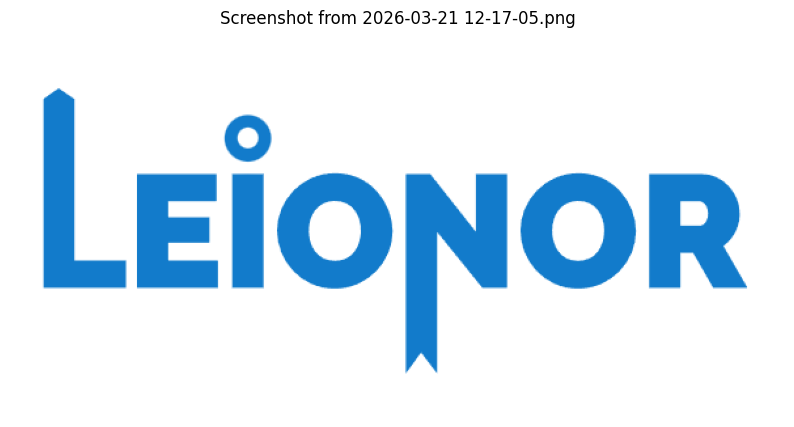

Size: (592, 294)  |  Mode: RGBA


In [13]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Find all images in data/ folder
image_files = list(Path('data').rglob('*.png')) + \
              list(Path('data').rglob('*.jpg')) + \
              list(Path('data').rglob('*.jpeg')) + \
              list(Path('data').rglob('*.webp'))

print(f'Found {len(image_files)} image(s):')
for i, f in enumerate(image_files):
    print(f'  [{i}] {f.name}')

# Display all images
for img_path in image_files:
    img = Image.open(img_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis('off')
    plt.show()
    print(f'Size: {img.size}  |  Mode: {img.mode}')